# Two basic checks on the one-unit GRU

*A deliberately small notebook. `analytical_rnn_fsc_wsls.ipynb` solved for GRU weights that
reproduce the fitted controller exactly, and then went a long way into dynamical systems. This
one steps back and asks two plain questions about the simplest case: a single hidden unit, on
the deterministic dataset. Nothing here depends on that notebook's later sections.*

## The setting, in one paragraph

On each trial you pick one of two arms and you either win or lose. The data was generated by
**win-stay/lose-shift**: if your last choice won, pick it again; if it lost, switch. A Finite
State Controller (FSC) fitted to 1000 sessions of that data came out as a **deterministic
2-state machine**, and `analytical_rnn_fsc_wsls.ipynb` §2 solved for GRU weights that satisfy
every one of that machine's requirements exactly, down to **one hidden unit**. §0.3 below
re-runs that solve, so this notebook stands alone.

## The two questions

**Q1. What is the one hidden unit actually doing?** We have weights that provably work. We have
not looked at the machinery. So: as each input arrives, what do the reset gate, the update gate,
the candidate ("new") value, and the hidden state itself do? And can you see the FSC's two states
in there?

> **Answer.** Yes, and completely. The solved network has exactly **four** internal
> configurations, one per row of the FSC's transition table, and its hidden state takes exactly
> **two** values, one per FSC memory state. The update gate is the whole mechanism: a win drives
> it to 1.0000, which means hold the state unchanged, and a loss drives it to about 0.1, which
> means overwrite. That is win-stay/lose-shift written as hold/reset. §1 shows all of it.

**Q2. Is the solved point somewhere training can stay?** Take the solved weights, hand them to
the optimiser as the starting point, and train. Does behaviour hold? Then knock the weights off
by a controlled amount and retrain: does the optimiser walk back, and how far can you push before
it cannot?

> **Answer, and it splits in two.** *Staying:* under cross entropy alone, yes, perfectly. Under
> the objective that actually produced the committed fits, **no**. The L1 penalty on the recurrent
> weights slowly eats the solution, and by 2000 epochs the rule is broken off the manifold, while
> on-manifold accuracy sits at 100% and the loss falls the whole way. §2.3 proves the penalty is
> the cause by switching it off. *Walking back:* yes, and from far away. Perturbations up to
> $\varepsilon = 3$ are undone by every seed, and random init at the same budget never gets there.

## One thing to expect before reading §2

**The loss will not be flat when we start from the solved weights, and that is not a failure.**
The pipeline notebook's §3.2b established why: cross entropy on deterministic data has no finite
minimiser. Once a network predicts the right action everywhere, the only thing left to do is
become *more certain*, which means growing the readout logits without bound, and the loss falls
like $1/t$ forever. On top of that the solver deliberately capped certainty at $0.9995$ and
tinyRNN adds an L1 penalty on the recurrent weights, so the solved point is provably **not** a
stationary point of the training objective.

So a falling loss says nothing about whether behaviour survived. It turns out to be worse than
uninformative here: §2.2 finds a run where the loss falls by two orders of magnitude, accuracy
never leaves 100%, and the machine is quietly destroyed underneath both of them. That is why every
run in §2 is judged by off-manifold behaviour first and the loss last.

## Roadmap

- §0 setup: the numpy GRU, the data, the fitted FSC, the committed trained H=1 fit, and a re-run
  of the solve.
- §1 Q1: the four rows, the gates, the two states, and where the trained network differs.
- §2 Q2: train from the solved weights, find what erodes them and prove what causes it, then
  perturb and retrain to see how far the optimiser can walk back from.
- §3 what these two checks establish.

## 0. Setup

Self-contained. The GRU is re-derived in plain numpy so every gate is visible; the fitted FSC and
the committed trained GRU are loaded from `fitted_models/`.

In [1]:
# --- 0.1 -- threads, imports, paths, the numpy GRU, and the loaders ------------------------
# THREADS FIRST, AND WHY. The solver in 0.3 is a Levenberg-Marquardt least-squares run whose
# path depends on the last bits of every matmul. Under multi-threaded BLAS those bits vary run
# to run, and the solve lands on a DIFFERENT exact solution each time -- specifically a mirrored
# one, h -> -h. Both are correct, but the printed numbers would not reproduce. Pinning to one
# thread makes this notebook's output stable. Must be set before numpy/torch are imported.
import os
for _v in ("OMP_NUM_THREADS", "MKL_NUM_THREADS", "VECLIB_MAXIMUM_THREADS", "OPENBLAS_NUM_THREADS"):
    os.environ[_v] = "1"

import sys, glob, pickle, shutil, time
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.func import jacrev
from scipy.optimize import least_squares

torch.set_num_threads(1)
torch.set_default_dtype(torch.float64)      # the solver works to ~1e-9; float32 cannot

# Cross-version pandas pickle compat, same shim the other notebooks use.
import pandas.core.arrays.string_ as _pd_str
from pandas.core.arrays._mixins import NDArrayBacked as _NDArrayBacked
def _compat_string_setstate(self, state):
    if isinstance(state, tuple) and len(state) == 2 and isinstance(state[1], np.ndarray):
        state = (state[0], state[1], {})
    return _NDArrayBacked.__setstate__(self, state)
_pd_str.StringArray.__setstate__ = _compat_string_setstate

REPO         = os.path.abspath(".")
FSC_SRC      = os.path.abspath("FSC-inference-MAPSO/src")
TINYRNN_ROOT = os.path.abspath("tinyRNN")
_COLLIDING   = ("utils", "FSC", "MAPSO", "parametrizations", "environments", "DiscreteObs")

def _use_fsc_path():
    if TINYRNN_ROOT in sys.path: sys.path.remove(TINYRNN_ROOT)
    if FSC_SRC not in sys.path:  sys.path.insert(0, FSC_SRC)
    for m in list(sys.modules):
        if m.split(".")[0] in _COLLIDING: del sys.modules[m]

def _use_tinyrnn_path():
    if FSC_SRC in sys.path:          sys.path.remove(FSC_SRC)
    if TINYRNN_ROOT not in sys.path: sys.path.insert(0, TINYRNN_ROOT)
    for m in list(sys.modules):
        if m.split(".")[0] in _COLLIDING: del sys.modules[m]

DATASET      = "det_init"     # the deterministic dataset: its fitted FSC is a deterministic machine
DATASET_FILE = "datasets/wsls_actions_observations_det_init.npz"
H            = 1              # the whole notebook is about the one-unit case
KMAX         = 80             # off-manifold probe length, same as the other notebooks

# ---- one GRU step in numpy, with the three gates exposed (torch nn.GRU equations) ----
def _sigmoid(x): return np.where(x >= 0, 1.0 / (1.0 + np.exp(-np.abs(x))),
                                 np.exp(-np.abs(x)) / (1.0 + np.exp(-np.abs(x))))
def _softmax(z):
    z = np.asarray(z, float); z = z - z.max(); e = np.exp(z); return e / e.sum()

def gru_step(h, x, P):
    """Returns (h', {reset r, update z, new n}).  h' = (1-z)*n + z*h;  z~1 hold, z~0 overwrite."""
    Hd = P["H"]
    gi = P["W_ih"] @ x + P["b_ih"]
    gh = P["W_hh"] @ h + P["b_hh"]
    r  = _sigmoid(gi[:Hd]     + gh[:Hd])
    z  = _sigmoid(gi[Hd:2*Hd] + gh[Hd:2*Hd])
    n  = np.tanh( gi[2*Hd:]   + r * gh[2*Hd:])
    return (1 - z) * n + z * h, {"reset": r, "update": z, "new": n}

def rnn_action_probs(h, P):
    return _softmax(h @ P["lin_W"].T + P["lin_b"])

def encode_input(a, y, A, Y):
    x = np.zeros(A + Y); x[a] = 1.0; x[A + y] = 1.0; return x

# ---- loaders -------------------------------------------------------------------------------
def load_dataset(path, n_max=1000, seed=0):
    raw = np.load(os.path.join(REPO, path))
    ra, ro = raw["actions"], raw["observations"]
    n_use = min(n_max, ra.shape[0])
    idx = (np.arange(ra.shape[0]) if n_use == ra.shape[0]
           else np.random.default_rng(seed).choice(ra.shape[0], n_use, replace=False))
    ActSpace = np.array(sorted(set(ra[idx].flatten().tolist())))
    ObsSpace = np.array(sorted(set(ro[idx].flatten().tolist())))
    a2i = {v: i for i, v in enumerate(ActSpace)}
    o2i = {v: i for i, v in enumerate(ObsSpace)}
    sessions = [{"actions":      np.array([a2i[a] for a in ra[i]], dtype=int),
                 "observations": np.array([o2i[o] for o in ro[i]], dtype=int)} for i in idx]
    win_idx = int(np.where(ObsSpace == 1)[0][0]) if 1 in ObsSpace.tolist() else len(ObsSpace) - 1
    return dict(ActSpace=ActSpace, ObsSpace=ObsSpace, A=len(ActSpace), Y=len(ObsSpace),
                win_idx=win_idx, lose_idx=1 - win_idx, sessions=sessions)

def extract_gru_params(agent):
    net = agent.model
    p = {k: v.detach().cpu().numpy() for k, v in net.rnn.named_parameters()}
    return {"W_ih": p["weight_ih_l0"], "W_hh": p["weight_hh_l0"],
            "b_ih": p["bias_ih_l0"],   "b_hh": p["bias_hh_l0"],
            "lin_W": net.lin.weight.detach().cpu().numpy(),
            "lin_b": net.lin.bias.detach().cpu().numpy(), "H": net.hidden_dim}

def load_trained_rnn(name, A, Y, Hd):
    """The committed tinyRNN fit at one hidden size, best trainval loss."""
    _use_tinyrnn_path()
    exp  = f"exp_{name}"
    live = f"files/saved_model/{exp}"
    arch = os.path.join(REPO, "fitted_models", name, "rnn", exp)
    cwd = os.getcwd(); os.chdir("tinyRNN")
    try:
        if os.path.isdir(arch) and not os.path.isdir(live): shutil.copytree(arch, live)
        from agents import Agent
        from analyzing_experiments.analyzing_perf import select_final_rnn_perf
        _, summary, _ = select_final_rnn_perf(exp, return_dim_est=True, verbose=False)
        rows = summary[summary["hidden_dim"] == Hd].sort_values("trainval_loss")
        cfg = {"agent_type": "RNN", "rnn_type": "GRU", "input_dim": A + Y, "hidden_dim": Hd,
               "output_dim": A, "device": "cpu", "output_h0": True, "trainable_h0": False,
               "readout_FC": True, "one_hot": False, "seed": 0}
        ag = Agent("RNN", config=cfg); ag.load(str(rows.iloc[0]["model_path"]))
        return extract_gru_params(ag)
    finally:
        os.chdir(cwd)

def load_fsc_machine(name):
    """The fitted FSC read off its own parameters: pi(a|m), g(m'|y,a,m), rho(m)."""
    _use_fsc_path()
    path = glob.glob(os.path.join(REPO, f"fitted_models/{name}/fsc/best_fsc_M*.pkl"))[0]
    with open(path, "rb") as f: fsc = pickle.load(f)
    fsc.set_mode("generation")
    pi  = np.asarray(fsc.get_action_policy())        # (M, A)
    g   = np.asarray(fsc.get_memory_transitions())   # (Y, A, M, M)
    rho = np.asarray(fsc.get_rho())                  # (M,)
    Tm  = np.asarray(fsc.get_TMat())                 # (Y, M, M, A)
    err = np.abs(Tm - pi[None, :, None, :] * np.transpose(g, (0, 2, 3, 1))).max()
    assert err < 1e-9, f"pi * g does not reproduce TMat (max err {err:.2e})"
    return dict(fsc=fsc, M=int(fsc.M), pi=pi, g=g, rho=rho, TMat=Tm)

def fsc_beliefs(FSC, actions, observations):
    """Forward filter. b[0] = rho, so b[t] is the belief held when choosing actions[t]."""
    Tm, rho_, Mm = FSC["TMat"], FSC["rho"], FSC["M"]
    b = rho_.copy(); out = [b.copy()]
    for t in range(len(actions)):
        bn = b @ Tm[int(observations[t]), :, :, int(actions[t])]
        s = bn.sum()
        b = bn / s if s > 0 else np.ones(Mm) / Mm
        out.append(b.copy())
    return np.array(out)

D    = load_dataset(DATASET_FILE)
A, Y = D["A"], D["Y"]
WIN, LOSE = D["win_idx"], D["lose_idx"]
FSC  = load_fsc_machine(DATASET)
M, pi, g, rho = FSC["M"], FSC["pi"], FSC["g"], FSC["rho"]
TRAINED = load_trained_rnn(DATASET, A, Y, H)
_use_fsc_path()

print(f"dataset {DATASET}: {len(D['sessions'])} sessions x {len(D['sessions'][0]['actions'])} trials")
print(f"  actions {D['ActSpace'].tolist()}, observations {D['ObsSpace'].tolist()} "
      f"-> win = index {WIN}, lose = index {LOSE}")
print(f"  fitted FSC: M = {M} memory states, policy pi(a|m) =\n{np.round(pi, 4)}")
print(f"  starts in m = {int(np.argmax(rho))}")
print(f"  trained GRU loaded at H = {TRAINED['H']}")

Searching for summary files...
Found 8 summary files.
Filtering by {'agent_type': 'RNN'}


  0%|          | 0/8 [00:00<?, ?it/s]

100%|██████████| 8/8 [00:00<00:00, 885.25it/s]

dataset det_init: 1000 sessions x 200 trials
  actions [-1, 1], observations [0, 1] -> win = index 1, lose = index 0
  fitted FSC: M = 2 memory states, policy pi(a|m) =
[[1. 0.]
 [0. 1.]]
  starts in m = 0
  trained GRU loaded at H = 1


In [2]:
# --- 0.2 -- plot style, matching the other notebooks so figures read side by side ----------
plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 120, "font.size": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.22, "grid.linewidth": 0.6,
    "axes.axisbelow": True, "legend.frameon": False,
})
C_FSC     = "#111111"    # the FSC: the reference, not a series hue
C_SOLVED  = "#1baf7a"    # green  -- the solved GRU
C_TRAINED = "#eb6834"    # orange -- the trained GRU
C_RULE    = "0.35"
C_STATE   = {0: "#2a78d6", 1: "#eb6834"}
SHADE     = "#8a8a86"

ACT_NAME = {i: f"a={D['ActSpace'][i]:+d}" for i in range(A)}
OBS_NAME = {WIN: "win", LOSE: "lose"}

# longest run of wins anywhere in the data: the edge of the region training ever saw
_runs = []
for s in D["sessions"]:
    r = 0
    for v in s["observations"]:
        r = r + 1 if v == WIN else 0
        _runs.append(r)
MAX_STREAK = int(max(_runs))

def shade_indata(ax, label=True):
    ax.axvspan(0, MAX_STREAK, color=SHADE, alpha=0.13, lw=0, zorder=0)
    if label:
        ax.text(MAX_STREAK, 0.02, f" longest streak\n in data (k={MAX_STREAK})", fontsize=7.5,
                color="0.4", ha="left", va="bottom", transform=ax.get_xaxis_transform())

print(f"Style ready. Longest win streak in {DATASET}: {MAX_STREAK} trials.")

Style ready. Longest win streak in det_init: 33 trials.


### 0.3 The solve, re-run here

Lifted unchanged from `analytical_rnn_fsc_wsls.ipynb` §2.1 so this notebook does not depend on it.
The idea in one line: every requirement of the form "the network must do X" becomes the number
(what it does) minus (what it must do), and a least-squares solver drives all of those to zero at
once. Nothing is trained.

In [3]:
# --- 0.3 -- the solver, and the H = 1 solve ------------------------------------------------
def _shapes(Hd, A, Y, M):
    return [("W_ih", (3*Hd, A+Y)), ("b_ih", (3*Hd,)), ("W_hh", (3*Hd, Hd)), ("b_hh", (3*Hd,)),
            ("lin_W", (A, Hd)), ("lin_b", (A,)), ("E", (Hd, M))]

def _unpack(theta, Hd, A, Y, M):
    out, i = {}, 0
    for k, sh in _shapes(Hd, A, Y, M):
        n = int(np.prod(sh)); out[k] = theta[i:i+n].reshape(sh); i += n
    return out

def machine_constraints(pi, g, rho, p_min=1e-6):
    """Every (state, action, observation) the machine can actually be in, plus the start state.
    Pairs with pi(a|m) = 0 are skipped: the machine never takes that action from that state, so
    the fitted g row there is unconstrained and means nothing."""
    M, A = pi.shape; Y = g.shape[0]
    trans = [(m, a, y, g[y, a, m]) for m in range(M) for a in range(A)
             if pi[m, a] > p_min for y in range(Y)]
    return trans, int(np.argmax(rho))

def solve_gru_for_fsc(pi, g, rho, Hd, conf=1e-3, pin_h0=True, lam=3e-2, restarts=5,
                      seed=0, exact_tol=1e-8):
    """Solve for GRU weights and an embedding E such that the GRU IS the machine (pi, g, rho).

    `conf`     how far the target policy is pulled off the vertices; the network's certainty cap.
               conf = 1e-3 means the network's best answer is 0.9995, never 1.0.
    `pin_h0`   require the start state to sit at h = 0, where tinyRNN starts every session.
    `restarts` independent random starts; among those that reach the exactness bar, keep the one
               with the smallest weights."""
    M, A = pi.shape; Y = g.shape[0]
    trans, m0 = machine_constraints(pi, g, rho)
    K = len(trans)
    npar = sum(int(np.prod(sh)) for _, sh in _shapes(Hd, A, Y, M))

    m_idx = torch.tensor([t[0] for t in trans])
    Xb = torch.zeros(K, A + Y)
    for i, (m, a, y, _) in enumerate(trans):
        Xb[i, a] = 1.0; Xb[i, A + y] = 1.0
    Gn      = torch.tensor(np.stack([t[3] for t in trans]))
    log_tgt = torch.tensor(np.log((1.0 - conf) * pi + conf / A))

    def residual_t(theta, lam_t):
        P = _unpack(theta, Hd, A, Y, M)
        E = P["E"]
        Hb = E[:, m_idx].T
        gi = Xb @ P["W_ih"].T + P["b_ih"]
        gh = Hb @ P["W_hh"].T + P["b_hh"]
        r  = torch.sigmoid(gi[:, :Hd]     + gh[:, :Hd])
        z  = torch.sigmoid(gi[:, Hd:2*Hd] + gh[:, Hd:2*Hd])
        n  = torch.tanh(   gi[:, 2*Hd:]   + r * gh[:, 2*Hd:])
        r_trans = ((1 - z) * n + z * Hb) - Gn @ E.T          # one GRU step vs the table's target
        r_read  = torch.log_softmax(E.T @ P["lin_W"].T + P["lin_b"], 1) - log_tgt
        parts = [r_trans.reshape(-1), r_read.reshape(-1)]
        if pin_h0: parts.append(E[:, m0])                    # start state at the origin
        parts.append(lam_t * theta)                          # ridge / tiebreaker
        return torch.cat(parts)

    jac_fn = jacrev(residual_t)
    def f(th, lv): return residual_t(torch.tensor(th), torch.tensor(lv)).numpy()
    def J(th, lv): return jac_fn(torch.tensor(th), torch.tensor(lv)).numpy()
    kw = dict(jac=J, method="lm", xtol=1e-15, ftol=1e-15, gtol=1e-15, max_nfev=5000)
    best, rng = None, np.random.default_rng(seed)
    for k in range(restarts):
        th = 0.5 * rng.standard_normal(npar)
        th = least_squares(f, th, args=(lam,),   **kw).x     # pass 1: a small-weight solution
        th = least_squares(f, th, args=(1e-12,), **kw).x     # pass 2: an exact one
        res = float(np.abs(f(th, 0.0)).max()); nrm = float(np.linalg.norm(th))
        key = (res > exact_tol, nrm)
        if best is None or key < best[0]: best = (key, res, th)
    _, res, th = best
    P = {k: v.numpy().copy() for k, v in _unpack(torch.tensor(th), Hd, A, Y, M).items()}
    E = P.pop("E"); P["H"] = Hd
    return P, E, res

TRANS, M0 = machine_constraints(pi, g, rho)
_t0 = time.time()
SOLVED, EMB, RESID = solve_gru_for_fsc(pi, g, rho, H)
print(f"solved H = {H} in {time.time() - _t0:.0f}s: worst requirement violation {RESID:.2e}")
print(f"  {len(TRANS)} reachable transition rows + {M} readouts + 1 start state = "
      f"{len(TRANS) + M + 1} requirements")
print(f"  the two memory states landed at h = {np.round(EMB.ravel(), 6).tolist()}")
print()
print("The solved weights, in full (rows grouped [reset | update | new], as torch orders them):")
_names = [f"r{i}" for i in range(H)] + [f"z{i}" for i in range(H)] + [f"n{i}" for i in range(H)]
print(f"   {'gate':>5}  {'W_ih (act0 act1 | obs0 obs1)':<34}  {'b_ih':>9}  {'W_hh':<10}  {'b_hh':>9}")
for i, nm in enumerate(_names):
    print(f"   {nm:>5}  {str(np.round(SOLVED['W_ih'][i], 4).tolist()):<34}  "
          f"{SOLVED['b_ih'][i]:>9.4f}  {str(np.round(SOLVED['W_hh'][i], 4).tolist()):<10}  "
          f"{SOLVED['b_hh'][i]:>9.4f}")
print(f"   readout  lin_W = {np.round(SOLVED['lin_W'], 4).tolist()}   "
      f"lin_b = {np.round(SOLVED['lin_b'], 4).tolist()}")

solved H = 1 in 10s: worst requirement violation 7.63e-09
  4 reachable transition rows + 2 readouts + 1 start state = 7 requirements
  the two memory states landed at h = [-0.0, 0.784113]

The solved weights, in full (rows grouped [reset | update | new], as torch orders them):
    gate  W_ih (act0 act1 | obs0 obs1)             b_ih  W_hh             b_hh
      r0  [0.1956, 0.0381, 0.2768, -0.0431]      0.2338  [0.0367]       0.2338
      z0  [2.1158, 0.5153, -8.682, 11.313]       2.6309  [0.4879]       2.6309
      n0  [1.9241, -0.9682, -0.0926, 1.0475]     0.9558  [-0.705]       0.6134
   readout  lin_W = [[-9.7867], [9.5993]]   lin_b = [3.7028, -3.8976]


## 1. Q1: what the one hidden unit is doing

### 1.1 There are only four situations, and here they all are

This is the point that makes the whole section short. The FSC has 2 memory states. Each state
takes **one** action with probability 1. There are 2 outcomes. So the number of situations the
machine can ever be in is

$$2 \text{ states} \times 1 \text{ action each} \times 2 \text{ outcomes} = 4.$$

Not 8, because a state never takes the other arm. Every trial of all 1000 sessions is one of
these four rows, so the table below is not a sample of the network's behaviour. It is **all** of
it, on the data manifold.

In [4]:
# --- 1.1 -- every situation the solved network can be in, exhaustively ----------------------
def gates_at(P, h, a, y):
    hn, gt = gru_step(np.atleast_1d(h).astype(float), encode_input(a, y, A, Y), P)
    return hn, gt

def nearest_state(hv, E):
    return int(np.argmin([abs(float(hv) - E[0, m]) for m in range(M)]))

print(f"{'from m':>6} {'h':>10} {'plays':>7} {'outcome':>7} | {'reset':>7} {'update':>7} "
      f"{'new':>7} | {'h next':>10} {'-> m':>5} {'table says':>11}   {'P(plays a=-1)':>13}")
ROWS = []
for (m, a, y, gn) in TRANS:
    h  = EMB[0, m]
    hn, gt = gates_at(SOLVED, h, a, y)
    lands  = nearest_state(hn[0], EMB)
    target = int(np.argmax(gn))
    p      = rnn_action_probs(np.array([h]), SOLVED)
    ROWS.append(dict(m=m, h=h, a=a, y=y, r=gt["reset"][0], z=gt["update"][0], n=gt["new"][0],
                     hn=hn[0], lands=lands, target=target))
    print(f"{m:>6} {h:>10.6f} {ACT_NAME[a]:>7} {OBS_NAME[y]:>7} | {gt['reset'][0]:>7.4f} "
          f"{gt['update'][0]:>7.4f} {gt['new'][0]:>7.4f} | {hn[0]:>10.6f} {lands:>5} "
          f"{target:>11}   {p[0]:>13.5f}")

_agree = all(r["lands"] == r["target"] for r in ROWS)
# Round before counting. The solve is exact to ~1e-8, not to machine precision, so the two
# state values appear as tight clusters rather than as bit-identical numbers; counting raw
# floats would report a spurious extra state at 8e-09.
_hs = sorted(set(np.round([r["h"] for r in ROWS] + [r["hn"] for r in ROWS], 6)))
print(f"\nEvery row lands where the FSC's table says it must: {_agree}")
print(f"Distinct values the hidden state ever takes (to 6 dp): {len(_hs)}  ->  "
      f"{[f'{v:+.6f}' for v in _hs]}")
for m in range(M):
    print(f"   h = {EMB[0, m]:+.6f} is memory state m={m}, which plays "
          f"{ACT_NAME[int(np.argmax(pi[m]))]}")
print("\nRead the 'update' column. On a WIN it is 1.0000 to four places, and h' = (1-z)*n + z*h")
print("with z = 1 is exactly h' = h: hold the state, unchanged, forever. On a LOSE it drops to")
print("about 0.1, so h' is almost entirely the candidate n, which carries it to the other state.")
print("That is win-stay/lose-shift, implemented as hold/overwrite, in one gate.")

from m          h   plays outcome |   reset  update     new |     h next  -> m  table says   P(plays a=-1)
     0  -0.000000    a=-1    lose |  0.7191  0.2134  0.9969 |   0.784113     1           1         0.99950
     0  -0.000000    a=-1     win |  0.6502  1.0000  0.9997 |   0.000000     0           0         0.99950
     1   0.784113    a=+1    lose |  0.6924  0.0743 -0.0629 |   0.000000     0           0         0.00050
     1   0.784113    a=+1     win |  0.6204  1.0000  0.7905 |   0.784113     1           1         0.00050

Every row lands where the FSC's table says it must: True
Distinct values the hidden state ever takes (to 6 dp): 2  ->  ['-0.000000', '+0.784113']
   h = -0.000000 is memory state m=0, which plays a=-1
   h = +0.784113 is memory state m=1, which plays a=+1

Read the 'update' column. On a WIN it is 1.0000 to four places, and h' = (1-z)*n + z*h
with z = 1 is exactly h' = h: hold the state, unchanged, forever. On a LOSE it drops to
about 0.1, so h' is almost entir

### 1.2 The same four rows as a picture, next to the trained network

Left column: the solved network, the four bars per gate being the four rows of the table above.
Right column: the trained H=1 fit driven by the same four inputs from **its own** two most
visited states, for comparison.

The row that matters is the update gate. The solved network's win bars sit at exactly 1.0, which
is the hold instruction. Nothing told the solver to use the update gate this way; it fell out of
requiring the network to be the machine.

trained H=1 typical hidden value per FSC state: m=0 -> -0.9041,  m=1 -> +0.9779
solved  H=1                                  : m=0 -> -0.0000,  m=1 -> +0.7841



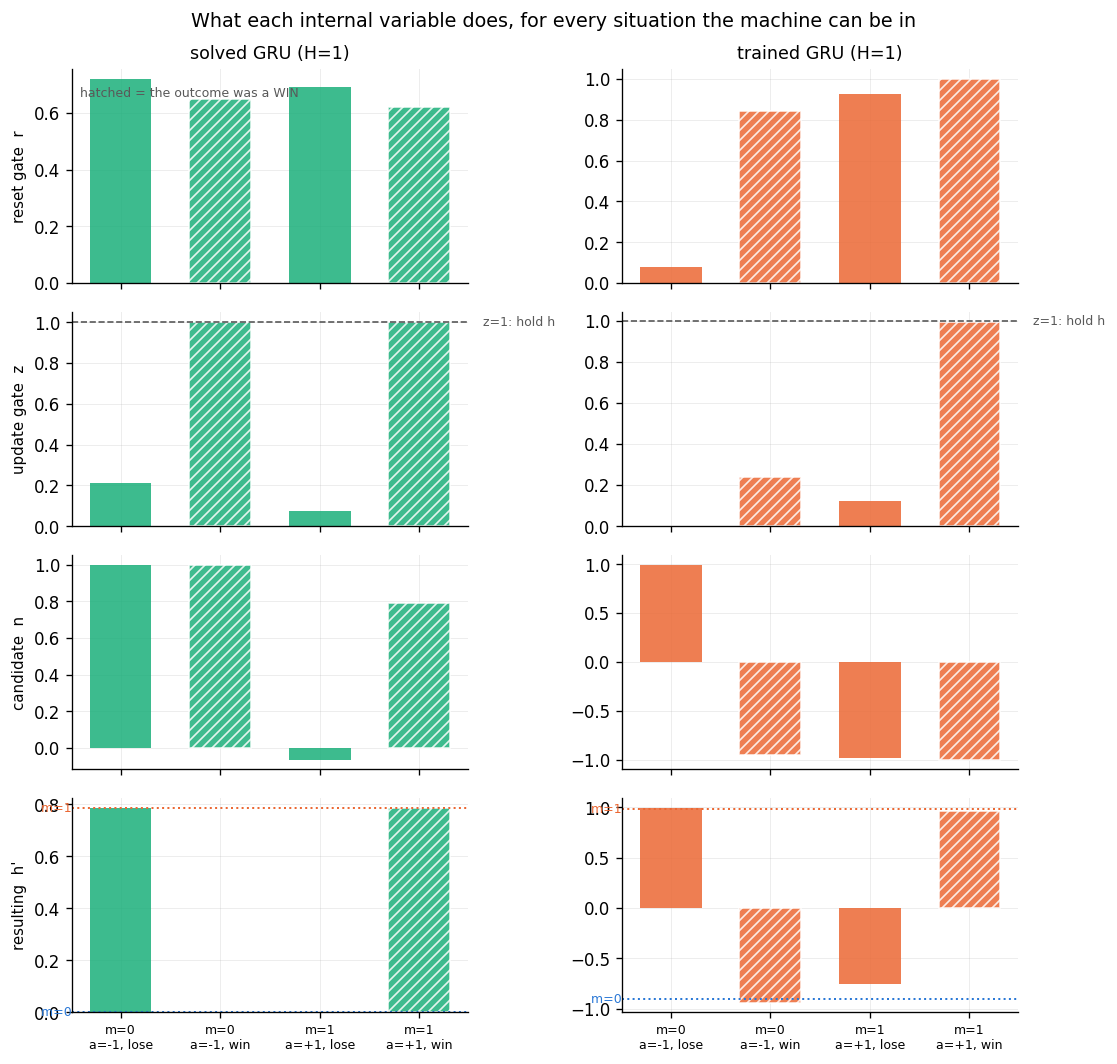

In [5]:
# --- 1.2 -- the gates, per situation, solved vs trained ------------------------------------
# The trained net has no memory states, so we give it the two hidden values it actually spends
# its time at: run it over the real data, take the h it holds when the FSC believes m=0 and m=1,
# and use the median of each. That is the fairest stand-in for "its state m".
def trained_state_values(P, n_sessions=200):
    hs = {0: [], 1: []}
    for s in D["sessions"][:n_sessions]:
        b = fsc_beliefs(FSC, s["actions"], s["observations"])[:-1]
        h = np.zeros(P["H"])
        for t in range(len(s["actions"])):
            hs[int(np.argmax(b[t]))].append(float(h[0]))
            h, _ = gru_step(h, encode_input(s["actions"][t], s["observations"][t], A, Y), P)
    return {m: float(np.median(v)) for m, v in hs.items()}

H_TRAINED = trained_state_values(TRAINED)
print(f"trained H=1 typical hidden value per FSC state: "
      f"m=0 -> {H_TRAINED[0]:+.4f},  m=1 -> {H_TRAINED[1]:+.4f}")
print(f"solved  H=1                                  : "
      f"m=0 -> {EMB[0,0]:+.4f},  m=1 -> {EMB[0,1]:+.4f}\n")

labels = [f"m={m}\n{ACT_NAME[a]}, {OBS_NAME[y]}" for (m, a, y, _) in TRANS]
xs = np.arange(len(TRANS))
fig, axes = plt.subplots(4, 2, figsize=(9.5, 9.0), sharex=True)
for col, (P, Ev, nm, cc) in enumerate((
        (SOLVED,  {m: EMB[0, m] for m in range(M)}, "solved GRU (H=1)",  C_SOLVED),
        (TRAINED, H_TRAINED,                        "trained GRU (H=1)", C_TRAINED))):
    vals = {k: [] for k in ("reset", "update", "new", "hnext")}
    for (m, a, y, _) in TRANS:
        hn, gt = gates_at(P, Ev[m], a, y)
        for k in ("reset", "update", "new"): vals[k].append(gt[k][0])
        vals["hnext"].append(hn[0])
    for row, (k, ttl) in enumerate((("reset", "reset gate  r"), ("update", "update gate  z"),
                                    ("new", "candidate  n"), ("hnext", "resulting  h'"))):
        ax = axes[row, col]
        wins = [i for i, (_, _, y, _) in enumerate(TRANS) if y == WIN]
        bars = ax.bar(xs, vals[k], color=cc, alpha=0.85, width=0.62)
        for i in wins: bars[i].set_hatch("////"); bars[i].set_edgecolor("white")
        if k == "update":
            ax.axhline(1.0, color=C_RULE, ls="--", lw=1.0)
            ax.text(len(xs) - 0.4, 1.0, " z=1: hold h", fontsize=7.5, color=C_RULE, va="center")
        if k == "hnext":
            for m in range(M):
                ax.axhline(Ev[m], color=C_STATE[m], ls=":", lw=1.2)
                ax.text(-0.45, Ev[m], f"m={m} ", fontsize=7.5, color=C_STATE[m],
                        ha="right", va="center")
        ax.set_ylabel(ttl if col == 0 else "", fontsize=9)
        if row == 0: ax.set_title(nm, fontsize=10.5)
axes[0, 0].text(0.02, 0.92, "hatched = the outcome was a WIN", transform=axes[0, 0].transAxes,
                fontsize=7.5, color="0.35", va="top")
for ax in axes[3]:
    ax.set_xticks(xs); ax.set_xticklabels(labels, fontsize=7.5)
fig.suptitle("What each internal variable does, for every situation the machine can be in",
             fontsize=11.5)
plt.tight_layout(); plt.show()

### 1.3 Over 1000 real sessions: how many internal states does each network actually use?

The table in §1.1 predicts 4 configurations and 2 hidden values for the solved network. This runs
both networks over the real data and counts, rather than assuming.

In [6]:
# --- 1.3 -- the (reset, update, new, h) cloud over real trials -----------------------------
def gate_cloud(P, sessions):
    """One row per trial: [reset, update, new, h], where h is the state the readout SAW."""
    R, Z, N, Hh = [], [], [], []
    for s in sessions:
        h = np.zeros(P["H"])
        for t in range(len(s["actions"])):
            Hh.append(h[0])
            h, gt = gru_step(h, encode_input(s["actions"][t], s["observations"][t], A, Y), P)
            R.append(gt["reset"][0]); Z.append(gt["update"][0]); N.append(gt["new"][0])
    return np.column_stack([R, Z, N, Hh])

def fsc_labels(sessions):
    return np.concatenate([np.argmax(fsc_beliefs(FSC, s["actions"], s["observations"])[:-1], 1)
                           for s in sessions])

SESS = D["sessions"]
CLOUD  = {"solved": gate_cloud(SOLVED, SESS), "trained": gate_cloud(TRAINED, SESS)}
LAB    = fsc_labels(SESS)
def n_clusters(V, tol):
    """How many groups the values fall into, if points within tol are the same point.
    Counting exact floats would be meaningless here: the solve is exact to ~1e-8, not to
    machine precision, so applying the recurrence 200 times a session leaves each state as a
    tight cloud rather than one repeated number. A tolerance says what 'the same state' means
    instead of letting a rounding decimal decide it."""
    s = np.sort(V)
    return 1 + int(np.sum(np.diff(s) > tol))

TOL = 1e-4
print(f"{len(LAB)} trials from {len(SESS)} sessions.")
print(f"Two values count as the same state when they are within {TOL:g} of each other.\n")
print(f"{'network':>9}  {'(r,z,n,h) groups':>17}  {'h groups':>9}  {'h range':>20}  "
      f"{'worst gap to its own state':>27}")
N_CFG, N_H, WORST = {}, {}, {}
for nm, Cd in CLOUD.items():
    # a generic 1-D projection, written elementwise: an @ here trips Accelerate's spurious
    # divide/overflow warnings, the same ones quiet_blas() guards against in 1.5
    proj = 1.0 * Cd[:, 0] + 1.7 * Cd[:, 1] + 2.3 * Cd[:, 2] + 3.1 * Cd[:, 3]
    N_CFG[nm] = n_clusters(proj, TOL)
    N_H[nm]   = n_clusters(Cd[:, 3], TOL)
    WORST[nm] = float(np.min(np.abs(Cd[:, 3][:, None] - EMB.ravel()[None, :]), axis=1).max())
    print(f"{nm:>9}  {N_CFG[nm]:>17}  {N_H[nm]:>9}  "
          f"{'[%+.4f, %+.4f]' % (Cd[:,3].min(), Cd[:,3].max()):>20}  {WORST[nm]:>27.2e}")

print(f"\nThe solved network: {N_CFG['solved']} configurations and {N_H['solved']} values of h "
      f"across all {len(LAB)} trials, which is")
print(f"what §1.1 said it would be, one per reachable table row and one per memory state. Its h")
print(f"never sits further than {WORST['solved']:.1e} from one of the two state values the solve")
print(f"placed, so 'two states' is a statement about all 200,000 trials and not about four rows.")
print(f"\nThe trained network: {N_CFG['trained']} configurations and {N_H['trained']} values of h, "
      f"wandering up to {WORST['trained']:.2f} away.")
print("Both get every trial right. They differ in whether the memory is discrete.")

200000 trials from 1000 sessions.
Two values count as the same state when they are within 0.0001 of each other.

  network   (r,z,n,h) groups   h groups               h range   worst gap to its own state
   solved                  4          2    [-0.0000, +0.7841]                     2.52e-07
  trained                541        225    [-0.9458, +0.9930]                     9.46e-01

The solved network: 4 configurations and 2 values of h across all 200000 trials, which is
what §1.1 said it would be, one per reachable table row and one per memory state. Its h
never sits further than 2.5e-07 from one of the two state values the solve
placed, so 'two states' is a statement about all 200,000 trials and not about four rows.

The trained network: 541 configurations and 225 values of h, wandering up to 0.95 away.
Both get every trial right. They differ in whether the memory is discrete.


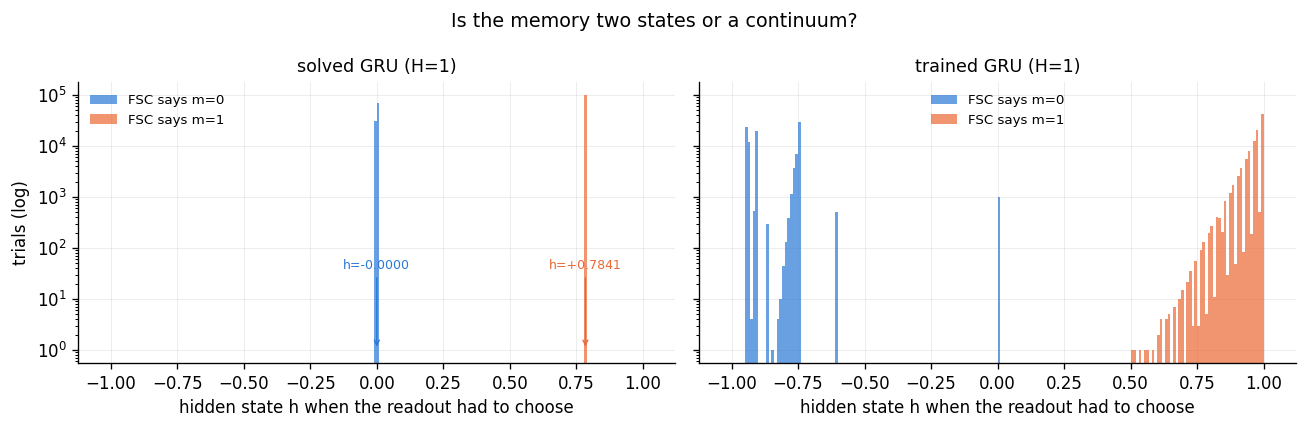

  solved: threshold on h recovers the FSC state 100.00% of trials;  between-state gap 0.7841,  widest within-state spread 0.0000
 trained: threshold on h recovers the FSC state 100.00% of trials;  between-state gap 1.8819,  widest within-state spread 0.9458

Both read the state off h perfectly. The difference is the spread: the solved network's
states have zero width, the trained one's are smeared, which is what §1.5 charges for.


In [7]:
# --- 1.4 -- where the hidden state actually sits, and the two-state test --------------------
fig, axes = plt.subplots(1, 2, figsize=(11.0, 3.6), sharey=True)
for ax, nm in zip(axes, ("solved", "trained")):
    Cd = CLOUD[nm]
    for m in range(M):
        ax.hist(Cd[LAB == m, 3], bins=np.linspace(-1.02, 1.02, 205), color=C_STATE[m],
                alpha=0.7, label=f"FSC says m={m}")
    ax.set_yscale("log"); ax.set_xlabel("hidden state h when the readout had to choose")
    ax.set_title(f"{nm} GRU (H=1)", fontsize=10.5)
    ax.legend(fontsize=8)
axes[0].set_ylabel("trials (log)")
for m in range(M):
    axes[0].annotate(f"h={EMB[0,m]:+.4f}", xy=(EMB[0, m], 1), xytext=(EMB[0, m], 40),
                     fontsize=7.5, ha="center", color=C_STATE[m],
                     arrowprops=dict(arrowstyle="->", color=C_STATE[m], lw=0.8))
fig.suptitle("Is the memory two states or a continuum?", fontsize=11.5)
plt.tight_layout(); plt.show()

# a number the caption can rest on: how well does a single threshold on h recover the FSC state?
for nm in ("solved", "trained"):
    hv = CLOUD[nm][:, 3]
    thr = 0.5 * (np.median(hv[LAB == 0]) + np.median(hv[LAB == 1]))
    side = (hv > thr).astype(int)
    acc  = max((side == LAB).mean(), (side != LAB).mean())
    gap  = np.abs(np.median(hv[LAB == 1]) - np.median(hv[LAB == 0]))
    within = max(np.ptp(hv[LAB == m]) for m in range(M))
    print(f"{nm:>8}: threshold on h recovers the FSC state {acc*100:6.2f}% of trials;  "
          f"between-state gap {gap:.4f},  widest within-state spread {within:.4f}")
print("\nBoth read the state off h perfectly. The difference is the spread: the solved network's")
print("states have zero width, the trained one's are smeared, which is what §1.5 charges for.")

### 1.5 PCA and t-SNE, pointed where they can say something

Two projections of the same 4-number space `(reset, update, new, h)`.

**On the solved network these are not run, on purpose.** It has 4 distinct points, all of them
printed in §1.1. PCA of 4 points returns those 4 points, and t-SNE of 4 points returns a layout
set by its perplexity and random seed rather than by the data. An exhaustive table is the stronger
statement, and we already have it.

**On the trained network they measure something real**, because its cloud has thousands of
distinct points. The question they answer: does that cloud still fall into two clusters matching
the FSC's states, or has the discrete structure dissolved?

PCA of the trained network's (reset, update, new, h) cloud, standardised:
   PC1:  73.94% of variance   loadings (r, z, n, h) = [0.555, 0.454, -0.524, 0.46]
   PC2:  16.19% of variance   loadings (r, z, n, h) = [-0.371, 0.561, 0.539, 0.508]
   PC3:   9.85% of variance   loadings (r, z, n, h) = [-0.011, -0.689, 0.028, 0.724]
   PC4:   0.01% of variance   loadings (r, z, n, h) = [0.745, -0.069, 0.659, -0.08]
   PC1 alone carries 73.94%, so the four variables are close to one underlying quantity.


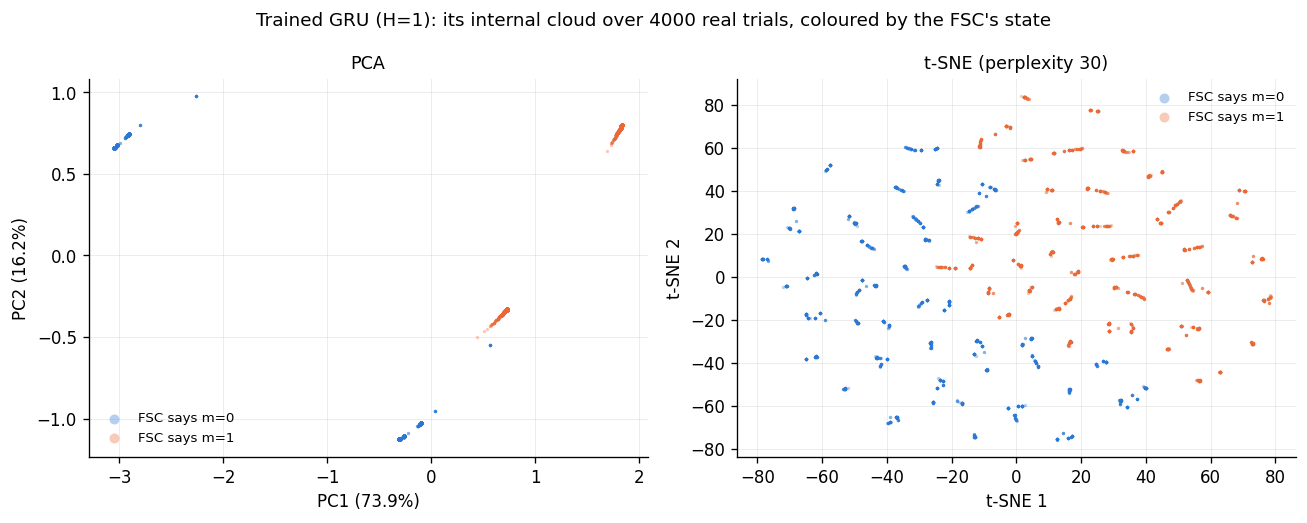

Both projections separate the two FSC states cleanly, so the trained network HAS the
two-state structure on the data. What it does not have is the solved network's exactness:
each cluster is an extended blob rather than a point, and §1.6 shows what that costs.


In [8]:
# --- 1.5 -- PCA and t-SNE of the TRAINED network's internal cloud ---------------------------
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from contextlib import contextmanager

@contextmanager
def quiet_blas():
    """Apple's Accelerate BLAS raises spurious divide/overflow warnings inside svd on inputs
    that are perfectly finite. Same guard the pipeline notebook uses."""
    old = np.seterr(all="ignore")
    try: yield
    finally: np.seterr(**old)

Xc = CLOUD["trained"]
Xs = (Xc - Xc.mean(0)) / Xc.std(0)          # standardised: gates and h have different scales

with quiet_blas():
    p = PCA().fit(Xs)
    Zp = p.transform(Xs)
print("PCA of the trained network's (reset, update, new, h) cloud, standardised:")
for i, v in enumerate(p.explained_variance_ratio_):
    print(f"   PC{i+1}: {v*100:6.2f}% of variance   loadings "
          f"(r, z, n, h) = {np.round(p.components_[i], 3).tolist()}")
print(f"   PC1 alone carries {p.explained_variance_ratio_[0]*100:.2f}%, so the four variables are"
      f" close to one underlying quantity.")

rng = np.random.default_rng(0)
sub = rng.choice(len(Xs), 4000, replace=False)
with quiet_blas():
    Zt = TSNE(n_components=2, init="pca", perplexity=30, random_state=0).fit_transform(Xs[sub])

fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.4))
for m in range(M):
    k = LAB[sub] == m
    axes[0].scatter(Zp[sub][k, 0], Zp[sub][k, 1], s=4, alpha=0.35, color=C_STATE[m],
                    label=f"FSC says m={m}", lw=0)
    axes[1].scatter(Zt[k, 0], Zt[k, 1], s=4, alpha=0.35, color=C_STATE[m],
                    label=f"FSC says m={m}", lw=0)
axes[0].set_xlabel(f"PC1 ({p.explained_variance_ratio_[0]*100:.1f}%)")
axes[0].set_ylabel(f"PC2 ({p.explained_variance_ratio_[1]*100:.1f}%)")
axes[0].set_title("PCA", fontsize=10.5)
axes[1].set_xlabel("t-SNE 1"); axes[1].set_ylabel("t-SNE 2")
axes[1].set_title("t-SNE (perplexity 30)", fontsize=10.5)
for ax in axes: ax.legend(fontsize=8, markerscale=3)
fig.suptitle("Trained GRU (H=1): its internal cloud over 4000 real trials, coloured by the "
             "FSC's state", fontsize=11)
plt.tight_layout(); plt.show()

print("Both projections separate the two FSC states cleanly, so the trained network HAS the")
print("two-state structure on the data. What it does not have is the solved network's exactness:")
print("each cluster is an extended blob rather than a point, and §1.6 shows what that costs.")

### 1.6 The long win streak, which is where the two networks part

This is the measurement from `rnn_offmanifold_finding.ipynb`: hand the network "you played this
arm and you won" over and over, past anything the data contains, and watch its confidence that it
should stay.

**Only a flat line is correct.** More winning evidence cannot make win-stay less true, so
flatness is the test and height is not.

Each network is driven into the state that plays the probed arm using only inputs the data
contains: it starts at $h_0 = 0$, which is the FSC's start state, and one win holds it there
while one loss moves it to the other state. That entry route needs no knowledge of the network's
embedding, so it applies unchanged to every network in §2.

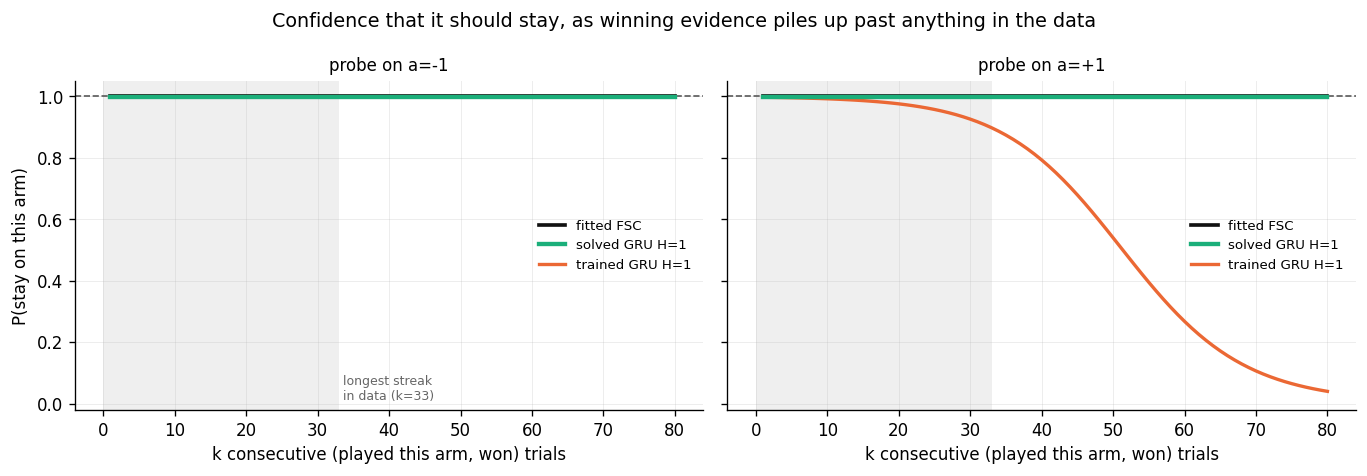

         network      arm       k=1     k=33     k=80   drift
      solved GRU     a=-1    0.9995   0.9995   0.9995   5.8e-09
      solved GRU     a=+1    0.9995   0.9995   0.9995   1.3e-10
     trained GRU     a=-1    0.9993   0.9996   0.9996   2.9e-04
     trained GRU     a=+1    0.9970   0.8977   0.0396   9.6e-01

solved  drift = 5.8e-09   (flat; its ceiling is the 0.9995 the solve chose)
trained drift = 9.6e-01

That is the whole cost of a smeared state. Both networks are right on every trial the
data contains. Off the manifold the solved one holds and the trained one does not.


In [9]:
# --- 1.6 -- the off-manifold win-streak probe ----------------------------------------------
M0_ACT = int(np.argmax(pi[M0]))            # the action the start state plays

def prime_h(P, a0):
    """From h0 = 0 (the start state), reach the state that plays a0 using one real input:
    a win holds the start state, a loss moves to the other one."""
    h = np.zeros(P["H"])
    y = WIN if a0 == M0_ACT else LOSE
    h, _ = gru_step(h, encode_input(M0_ACT, y, A, Y), P)
    return h

def probe_curve(P, a0, kmax=KMAX):
    """P(stay on a0) after k consecutive (played a0, won) trials, k = 1..kmax."""
    h = prime_h(P, a0); x = encode_input(a0, WIN, A, Y); out = []
    for _ in range(kmax):
        h, _ = gru_step(h, x, P); out.append(rnn_action_probs(h, P)[a0])
    return np.array(out)

def fsc_probe(a0, kmax=KMAX):
    b = rho.copy()
    y = WIN if a0 == M0_ACT else LOSE
    bn = b @ FSC["TMat"][y, :, :, M0_ACT]; b = bn / bn.sum()
    out = []
    for _ in range(kmax):
        bn = b @ FSC["TMat"][WIN, :, :, a0]; s = bn.sum()
        b = bn / s if s > 0 else b
        out.append(float((b @ pi)[a0]))
    return np.array(out)

def probe_drift(P, kmax=KMAX):
    """The single number: worst over both arms of (max - min) of P(stay) across the streak."""
    return max(float(np.ptp(probe_curve(P, a0, kmax))) for a0 in range(A))

kk = np.arange(1, KMAX + 1)
fig, axes = plt.subplots(1, A, figsize=(11.5, 4.0), sharey=True)
for a0 in range(A):
    ax = axes[a0]
    shade_indata(ax, label=(a0 == 0))
    ax.axhline(1.0, color=C_RULE, ls="--", lw=1.0)
    ax.plot(kk, fsc_probe(a0),           color=C_FSC,     lw=2.2, label="fitted FSC", zorder=5)
    ax.plot(kk, probe_curve(SOLVED, a0), color=C_SOLVED,  lw=2.6, label="solved GRU H=1", zorder=6)
    ax.plot(kk, probe_curve(TRAINED, a0),color=C_TRAINED, lw=2.0, label="trained GRU H=1")
    ax.set_xlabel("k consecutive (played this arm, won) trials")
    ax.set_title(f"probe on {ACT_NAME[a0]}", fontsize=10)
    ax.set_ylim(-0.02, 1.05); ax.legend(fontsize=8, loc="center right")
axes[0].set_ylabel("P(stay on this arm)")
fig.suptitle("Confidence that it should stay, as winning evidence piles up past anything in the data",
             fontsize=11.5)
plt.tight_layout(); plt.show()

print(f"{'network':>16}  {'arm':>7}  {'k=1':>8} {'k=%d' % MAX_STREAK:>8} {'k=%d' % KMAX:>8}   drift")
for nm, P in (("solved GRU", SOLVED), ("trained GRU", TRAINED)):
    for a0 in range(A):
        c = probe_curve(P, a0)
        print(f"{nm:>16}  {ACT_NAME[a0]:>7}  {c[0]:>8.4f} {c[MAX_STREAK-1]:>8.4f} "
              f"{c[-1]:>8.4f}   {np.ptp(c):.1e}")
print(f"\nsolved  drift = {probe_drift(SOLVED):.1e}   (flat; its ceiling is the 0.9995 the solve chose)")
print(f"trained drift = {probe_drift(TRAINED):.1e}")
print("\nThat is the whole cost of a smeared state. Both networks are right on every trial the")
print("data contains. Off the manifold the solved one holds and the trained one does not.")

## 2. Q2: can training stay at the solved weights, and can it walk back to them?

### 2.1 The training setup, matched to the committed fits

To compare fairly with the trained GRU, the optimiser has to be the one that produced it. Read off
`scripts/train_rnn_parallel.py` and tinyRNN's `RNNAgentTrainer`:

| | |
|---|---|
| optimiser | `AdamW`, `lr = 0.005`, `weight_decay = 0` |
| loss | cross entropy on the action, plus `1e-5` times the L1 norm of `weight_ih_l0` and `weight_hh_l0` |
| batching | full batch, all sessions every step |
| initial state | `h0 = 0`, not trainable |
| readout | full connected linear, and `output_h0 = True`, so `readout(h_t)` predicts `action_t` |

One deliberate departure: we train on all 1000 sessions rather than tinyRNN's nested CV folds.
The question here is about the shape of the loss surface around a known point, not about
generalisation, and on deterministic data the train/test gap is zero anyway. The cell below checks
the harness against the numpy GRU used everywhere above, so the two halves of this notebook are
measuring the same object.

In [10]:
# --- 2.1 -- the training harness, and the checks that it is the right one -------------------
LR, L1W, EPOCHS = 0.005, 1e-5, 2000     # EPOCHS matches tinyRNN's max_epoch_num

def build_tensors(sessions):
    """(T, B, A+Y) input and (T, B) target, laid out the way tinyRNN's SimpleDataset does."""
    T = len(sessions[0]["actions"]); B = len(sessions)
    X = np.zeros((T, B, A + Y)); Tg = np.zeros((T, B), dtype=np.int64)
    for b, s in enumerate(sessions):
        X[np.arange(T), b, s["actions"]] = 1.0
        X[np.arange(T), b, A + s["observations"]] = 1.0
        Tg[:, b] = s["actions"]
    return torch.tensor(X), torch.tensor(Tg)

XT, TT = build_tensors(SESS)

class TinyGRU(nn.Module):
    """The graph tinyRNN builds for (GRU, readout_FC=True, trainable_h0=False, output_h0=True)."""
    def __init__(self, Hd):
        super().__init__()
        self.rnn = nn.GRU(A + Y, Hd); self.lin = nn.Linear(Hd, A); self.Hd = Hd
    def forward(self, X):
        h0 = torch.zeros(1, X.shape[1], self.Hd, dtype=X.dtype)
        out, _ = self.rnn(X, h0)
        out = torch.cat((h0, out), 0)      # output_h0 = True
        return self.lin(out)[:-1]          # scores[:-1] aligns readout(h_t) with action_t

def to_model(P):
    m = TinyGRU(P["H"]).double()
    with torch.no_grad():
        m.rnn.weight_ih_l0.copy_(torch.tensor(P["W_ih"]))
        m.rnn.weight_hh_l0.copy_(torch.tensor(P["W_hh"]))
        m.rnn.bias_ih_l0.copy_(torch.tensor(P["b_ih"]))
        m.rnn.bias_hh_l0.copy_(torch.tensor(P["b_hh"]))
        m.lin.weight.copy_(torch.tensor(P["lin_W"]))
        m.lin.bias.copy_(torch.tensor(P["lin_b"]))
    return m

def to_params(m):
    gt = lambda x: x.detach().numpy().copy()
    return {"W_ih": gt(m.rnn.weight_ih_l0), "W_hh": gt(m.rnn.weight_hh_l0),
            "b_ih": gt(m.rnn.bias_ih_l0),   "b_hh": gt(m.rnn.bias_hh_l0),
            "lin_W": gt(m.lin.weight), "lin_b": gt(m.lin.bias), "H": m.Hd}

_ce = nn.CrossEntropyLoss()
def behav_loss(m):  return _ce(m(XT).reshape(-1, A), TT.reshape(-1))
def l1_term(m):     return L1W * (m.rnn.weight_ih_l0.abs().sum() + m.rnn.weight_hh_l0.abs().sum())

def train_from(P, epochs=EPOCHS, seed=0):
    torch.manual_seed(seed)
    m = to_model(P)
    opt = torch.optim.AdamW(m.parameters(), lr=LR, weight_decay=0.0)
    curve = np.empty(epochs)
    for e in range(epochs):
        opt.zero_grad()
        bl = behav_loss(m)
        (bl + l1_term(m)).backward()
        opt.step()
        curve[e] = bl.item()
    return to_params(m), curve

# CHECK 1: the torch graph and the numpy GRU are the same network
_s = SESS[0]
with torch.no_grad(): _sc = to_model(SOLVED)(XT[:, :1])[:, 0].numpy()
_h, _mx = np.zeros(H), 0.0
for t in range(len(_s["actions"])):
    _mx = max(_mx, np.abs(_softmax(_sc[t]) - rnn_action_probs(_h, SOLVED)).max())
    _h, _ = gru_step(_h, encode_input(_s["actions"][t], _s["observations"][t], A, Y), SOLVED)
print(f"torch graph vs numpy GRU, worst |dP| over a full session: {_mx:.1e}")

# CHECK 2: the loss the harness reports at each known set of weights
with torch.no_grad():
    _ce_solved  = behav_loss(to_model(SOLVED)).item()
    _ce_trained = behav_loss(to_model(TRAINED)).item()
print(f"cross entropy on all {len(SESS)} sessions:  solved {_ce_solved:.6f}   "
      f"trained {_ce_trained:.6f}")
print(f"   the solved value is exactly -ln(0.9995) = {-np.log(0.9995):.6f}, the certainty cap the")
print(f"   solve chose. It is not a fitting error; it is the conf setting, and training can and")
print(f"   will push past it.")

torch graph vs numpy GRU, worst |dP| over a full session: 2.2e-16
cross entropy on all 1000 sessions:  solved 0.000500   trained 0.003428
   the solved value is exactly -ln(0.9995) = 0.000500, the certainty cap the
   solve chose. It is not a fitting error; it is the conf setting, and training can and
   will push past it.


### 2.2 Start at the solved weights and train, under the objective that made the committed fits

Three things get measured, in this order of importance:

1. **off-manifold drift**, the §1.6 number: worst over both arms of how far P(stay) moves across
   an 80-win streak. Win-stay says this must be 0.
2. **on-manifold accuracy**: fraction of all 200,000 real trials whose most likely action is the
   one the data took.
3. **loss**, read last, for the reason given in the intro.

A run counts as **holding the rule** if accuracy is 100% and drift is below $10^{-2}$, the same
threshold `analytical_rnn_fsc_wsls.ipynb` §4.4 used.

The run below also records what is happening to the machinery, because the headline result needs
it: the smallest value the update gate takes on a win. §1 showed that gate sitting at 1.0000, which
is the instruction "hold the state exactly". Watch what training does to it.

In [11]:
# --- 2.2 -- train from the solved weights, tracking the machinery as well as the loss --------
def on_manifold_acc(P):
    """Fraction of all real trials whose most likely action is the one the data took.
    Run through the torch graph rather than the numpy loop purely for speed; 2.1 checked the
    two agree to 1e-16, and this gets called after every one of the runs in 2.5."""
    with torch.no_grad():
        pred = to_model(P)(XT).argmax(-1)
    return float((pred == TT).double().mean())

def min_z_on_win(P):
    """The smallest update-gate value on a winning input, taken from each memory state.
    z = 1 means 'hold h exactly'. Anything below 1 leaks a little of the state away on every
    winning trial, and an 80-trial streak compounds the leak 80 times."""
    out = []
    for m in range(M):
        _, gt = gru_step(np.array([EMB[0, m]]), encode_input(int(np.argmax(pi[m])), WIN, A, Y), P)
        out.append(gt["update"][0])
    return float(min(out))

def rec_l1(P):
    """What the L1 penalty in the objective is actually charging for."""
    return float(np.abs(P["W_ih"]).sum() + np.abs(P["W_hh"]).sum())

DRIFT_TOL = 1e-2
def verdict(P):
    a, d = on_manifold_acc(P), probe_drift(P)
    return a, d, (a > 0.99995 and d < DRIFT_TOL)

def train_tracked(P, epochs=EPOCHS, seed=0, every=200, l1w=L1W):
    """train_from, plus a snapshot of the behaviour and the machinery every `every` epochs."""
    torch.manual_seed(seed)
    m = to_model(P)
    opt = torch.optim.AdamW(m.parameters(), lr=LR, weight_decay=0.0)
    curve, log = np.empty(epochs), []
    def snap(e):
        Q = to_params(m)
        log.append(dict(epoch=e, drift=probe_drift(Q), acc=on_manifold_acc(Q),
                        z=min_z_on_win(Q), rl1=rec_l1(Q), linW=float(np.abs(Q["lin_W"]).max())))
    for e in range(epochs):
        if e % every == 0: snap(e)
        opt.zero_grad()
        bl = behav_loss(m)
        (bl + l1w * (m.rnn.weight_ih_l0.abs().sum() + m.rnn.weight_hh_l0.abs().sum())).backward()
        opt.step()
        curve[e] = bl.item()
    snap(epochs)
    return to_params(m), curve, log

_t0 = time.time()
P_FROM_SOLVED, CURVE_SOLVED, LOG_SOLVED = train_tracked(SOLVED)
print(f"{EPOCHS} epochs from the solved weights: {time.time() - _t0:.0f}s\n")

KEYS = ("W_ih", "W_hh", "b_ih", "b_hh", "lin_W", "lin_b")
flat = lambda P: np.concatenate([np.asarray(P[k]).ravel() for k in KEYS])
TH0  = flat(SOLVED)

print(f"{'epoch':>6} {'loss':>10} {'accuracy':>9} {'drift':>10}   "
      f"{'min z on win':>13} {'L1(recurrent)':>14} {'max|lin_W|':>11}")
for s in LOG_SOLVED:
    lo = CURVE_SOLVED[min(s["epoch"], EPOCHS - 1)]
    print(f"{s['epoch']:>6} {lo:>10.6f} {s['acc']:>9.5f} {s['drift']:>10.2e}   "
          f"{s['z']:>13.8f} {s['rl1']:>14.3f} {s['linW']:>11.3f}")

a1, d1, ok1 = verdict(P_FROM_SOLVED)
print(f"\nAfter {EPOCHS} epochs: accuracy {a1:.5f}, drift {d1:.2e}  ->  "
      f"{'holds the rule' if ok1 else 'BROKEN, drift is above the %g tolerance' % DRIFT_TOL}")
print(f"weights moved by ||dtheta|| = {np.linalg.norm(flat(P_FROM_SOLVED) - TH0):.3f} "
      f"(the solved weights themselves have norm {np.linalg.norm(TH0):.3f})")
_a, _b = LOG_SOLVED[0], LOG_SOLVED[-1]
print(f"\nRead the last three columns together, because they are one story.")
print(f"  recurrent L1 norm   {_a['rl1']:.3f} -> {_b['rl1']:.3f}   "
      f"({'shrinking' if _b['rl1'] < _a['rl1'] else 'growing'}: the penalty charges for it)")
print(f"  min z on a win      {_a['z']:.8f} -> {_b['z']:.8f}   "
      f"(the 'hold h exactly' instruction, built out of those same large weights)")
print(f"  off-manifold drift  {_a['drift']:.2e} -> {_b['drift']:.2e}   "
      f"({'grew %.0fx' % (_b['drift'] / _a['drift']) if _b['drift'] > _a['drift'] else 'flat'})")
print(f"  on-manifold accuracy stayed at {_b['acc']*100:.3f}% and the loss fell "
      f"{CURVE_SOLVED[0] / CURVE_SOLVED[-1]:.0f}x throughout")
if _b["drift"] > DRIFT_TOL:
    print(f"\nA gap of {1 - _b['z']:.2e} in the hold gate looks like nothing. Compounded over an")
    print(f"{KMAX}-trial streak it is not, and by epoch {EPOCHS} the rule is broken off the manifold")
    print(f"while both of the quantities you would normally watch, the loss and the accuracy, stay")
    print(f"silent about it the whole way. §2.3 pins down what is doing the eroding.")
else:
    print(f"\nAt this budget the erosion has not yet crossed the {DRIFT_TOL:g} tolerance. §2.3 still")
    print(f"isolates what drives it, since the direction of travel is already visible above.")

2000 epochs from the solved weights: 39s

 epoch       loss  accuracy      drift    min z on win  L1(recurrent)  max|lin_W|
     0   0.000500   1.00000   5.84e-09      0.99999997         28.442       9.787
   200   0.000021   1.00000   6.13e-08      0.99999984         24.990      10.144
   400   0.000017   1.00000   2.04e-07      0.99999924         22.741      10.344
   600   0.000014   1.00000   6.16e-07      0.99999707         21.017      10.551
   800   0.000011   1.00000   1.77e-06      0.99999103         19.610      10.752
  1000   0.000009   1.00000   5.27e-06      0.99997306         18.265      10.951
  1200   0.000008   1.00000   1.61e-05      0.99992032         16.899      11.148
  1400   0.000007   1.00000   5.28e-05      0.99976727         15.504      11.343
  1600   0.000006   1.00000   2.06e-04      0.99932869         14.111      11.532
  1800   0.000005   1.00000   1.54e-03      0.99812342         12.683      11.716
  2000   0.000005   1.00000   8.41e-02      0.99517646  

### 2.3 Is it the L1 penalty, or is it training itself?

The table above is suggestive but circumstantial. The decisive test is one line: run the identical
thing with `l1_weight = 0` and nothing else changed. If the erosion is a property of gradient
descent on this loss, it happens anyway. If it is the penalty, it stops.

In [12]:
# --- 2.3 -- the same run with the L1 penalty switched off ----------------------------------
_t0 = time.time()
P_NO_L1, CURVE_NO_L1, LOG_NO_L1 = train_tracked(SOLVED, l1w=0.0)
print(f"{EPOCHS} epochs, l1_weight = 0: {time.time() - _t0:.0f}s\n")

print(f"{'':>26} {'drift @0':>10} {'drift @%d' % EPOCHS:>11}   "
      f"{'min z @0':>11} {'min z @%d' % EPOCHS:>13}   {'L1(rec) @0':>11} {'L1(rec) @%d' % EPOCHS:>13}")
for nm, lg in (("l1_weight = 1e-5 (pipeline)", LOG_SOLVED), ("l1_weight = 0", LOG_NO_L1)):
    print(f"{nm:>26} {lg[0]['drift']:>10.2e} {lg[-1]['drift']:>11.2e}   "
          f"{lg[0]['z']:>11.8f} {lg[-1]['z']:>13.8f}   {lg[0]['rl1']:>11.3f} {lg[-1]['rl1']:>13.3f}")

a2, d2, ok2 = verdict(P_NO_L1)
print(f"\nWithout the penalty: accuracy {a2:.5f}, drift {d2:.2e}  ->  "
      f"{'holds the rule' if ok2 else 'broken'}")
print(f"loss reached {CURVE_NO_L1[-1]:.6f} (with the penalty it reached {CURVE_SOLVED[-1]:.6f})")
print(f"\nThat settles it. With the penalty off, the recurrent weights GROW "
      f"({LOG_NO_L1[0]['rl1']:.1f} -> {LOG_NO_L1[-1]['rl1']:.1f}),")
print(f"the hold instruction stays saturated, and after {EPOCHS} epochs the drift is "
      f"{LOG_NO_L1[-1]['drift']:.1e}, which is where")
print(f"it started. The solved point is a place cross entropy is perfectly happy to sit.")
print(f"\nThe erosion in 2.2 is the L1 penalty, and the conflict is structural rather than bad luck:")
print(f"an exact gate needs a large weight to saturate it, and L1 is a charge on exactly that. The")
print(f"committed fits in fitted_models/ were all trained with l1_weight = 1e-5, so the pipeline's")
print(f"own regulariser prices the exact solution out. That is a property of the objective, not of")
print(f"the architecture, and §1 already showed the architecture can hold the rule.")

2000 epochs, l1_weight = 0: 38s

                             drift @0 drift @2000      min z @0   min z @2000    L1(rec) @0 L1(rec) @2000
l1_weight = 1e-5 (pipeline)   5.84e-09    8.41e-02    0.99999997    0.99517646        28.442        11.276
             l1_weight = 0   5.84e-09    8.66e-09    0.99999997    0.99999996        28.442        31.741

Without the penalty: accuracy 1.00000, drift 8.66e-09  ->  holds the rule
loss reached 0.000003 (with the penalty it reached 0.000005)

That settles it. With the penalty off, the recurrent weights GROW (28.4 -> 31.7),
the hold instruction stays saturated, and after 2000 epochs the drift is 8.7e-09, which is where
it started. The solved point is a place cross entropy is perfectly happy to sit.

The erosion in 2.2 is the L1 penalty, and the conflict is structural rather than bad luck:
an exact gate needs a large weight to saturate it, and L1 is a charge on exactly that. The
committed fits in fitted_models/ were all trained with l1_weight = 1

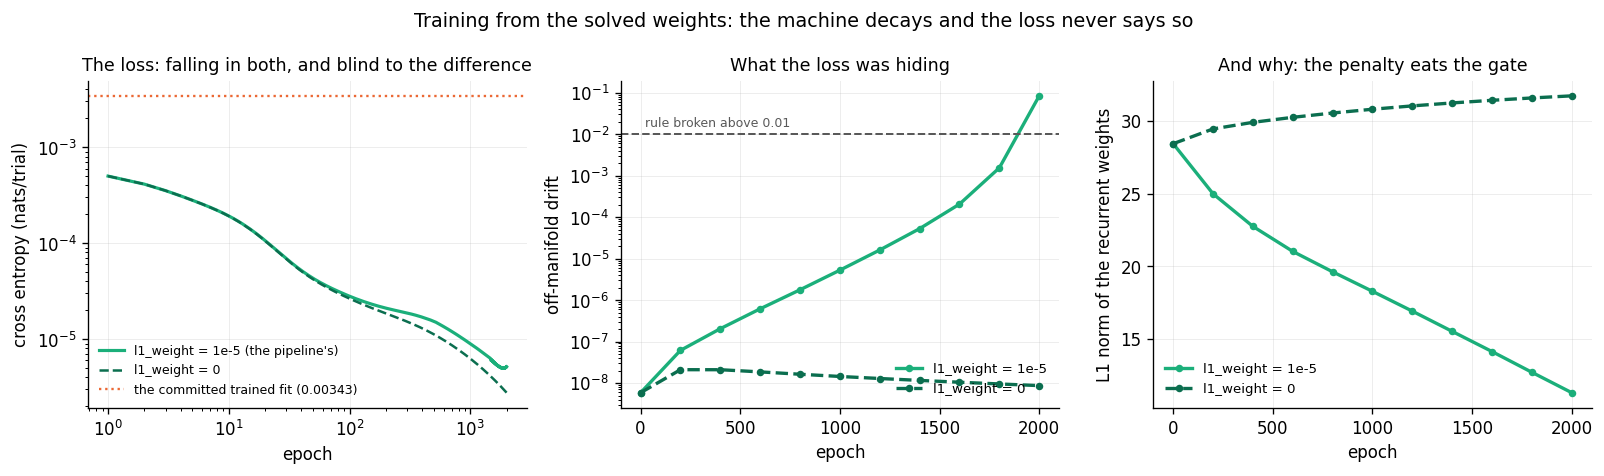

In [13]:
# --- 2.4 -- the two runs side by side --------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.0))
ep = np.arange(1, EPOCHS + 1)

ax = axes[0]
ax.plot(ep, CURVE_SOLVED, color=C_SOLVED, lw=1.9, label="l1_weight = 1e-5 (the pipeline's)")
ax.plot(ep, CURVE_NO_L1,  color="#0b6e4f", lw=1.5, ls="--", label="l1_weight = 0")
ax.axhline(_ce_trained, color=C_TRAINED, ls=":", lw=1.4,
           label=f"the committed trained fit ({_ce_trained:.5f})")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("epoch"); ax.set_ylabel("cross entropy (nats/trial)")
ax.set_title("The loss: falling in both, and blind to the difference", fontsize=10.5)
ax.legend(fontsize=7.5, loc="lower left")

ax = axes[1]
for lg, cc, ls, nm in ((LOG_SOLVED, C_SOLVED, "-", "l1_weight = 1e-5"),
                       (LOG_NO_L1, "#0b6e4f", "--", "l1_weight = 0")):
    ax.plot([s["epoch"] for s in lg], [max(s["drift"], 1e-12) for s in lg],
            color=cc, ls=ls, lw=2.0, marker="o", ms=3.5, label=nm)
ax.axhline(DRIFT_TOL, color=C_RULE, ls="--", lw=1.2)
ax.text(20, DRIFT_TOL * 1.5, f"rule broken above {DRIFT_TOL:g}", fontsize=7.5, color=C_RULE)
ax.set_yscale("log")
ax.set_xlabel("epoch"); ax.set_ylabel("off-manifold drift")
ax.set_title("What the loss was hiding", fontsize=10.5)
ax.legend(fontsize=8, loc="lower right")

ax = axes[2]
for lg, cc, ls, nm in ((LOG_SOLVED, C_SOLVED, "-", "l1_weight = 1e-5"),
                       (LOG_NO_L1, "#0b6e4f", "--", "l1_weight = 0")):
    ax.plot([s["epoch"] for s in lg], [s["rl1"] for s in lg], color=cc, ls=ls, lw=2.0,
            marker="o", ms=3.5, label=nm)
ax.set_xlabel("epoch"); ax.set_ylabel("L1 norm of the recurrent weights")
ax.set_title("And why: the penalty eats the gate", fontsize=10.5)
ax.legend(fontsize=8)

fig.suptitle("Training from the solved weights: the machine decays and the loss never says so",
             fontsize=11.5)
plt.tight_layout(); plt.show()

### 2.5 Knock it off the solved point, then retrain

Now the second half of the question. Add Gaussian noise of standard deviation $\varepsilon$ to
**every** parameter and train from there, under the pipeline objective. Does the optimiser walk
back to a network that holds win-stay, and how large does $\varepsilon$ have to get before it
cannot?

For scale: the solved weight vector has 25 numbers and norm about 21, and its largest single
weight is about 11. So $\varepsilon = 1$ is a large knock and $\varepsilon = 16$ leaves essentially
nothing of the original.

**Read these runs against §2.2, not against a perfect target.** Every run here is subject to the
same L1 erosion, so a run that ends at drift $10^{-3}$ has not found a permanently safe place; it
is somewhere earlier on the same decay curve that §2.2 measured. The question the ladder answers
is whether the optimiser comes *back to the right machine*, not whether it stays there forever.

Three seeds per size, because near the boundary the answer stops being the same every time. The
last block is the control that gives the comparison meaning: the same optimiser and budget started
from a **random** init, which is how the committed fits were made.

In [14]:
# --- 2.5 -- the perturbation ladder ---------------------------------------------------------
def perturb(P, eps, seed):
    rng = np.random.default_rng(seed)
    Q = {k: np.asarray(P[k]) + eps * rng.standard_normal(np.asarray(P[k]).shape) for k in KEYS}
    Q["H"] = P["H"]; return Q

EPS_LADDER = [0.0, 0.5, 1.0, 2.0, 3.0, 4.0, 8.0, 16.0]
SEEDS      = [0, 1, 2]
RESULTS, CURVES = [], {}

print(f"{'run':>13} | {'||dtheta||':>10} {'acc@init':>9} {'drift@init':>11} | "
      f"{'loss@end':>9} {'acc@end':>9} {'drift@end':>11} | {'verdict':>9}")
_t0 = time.time()
for eps in EPS_LADDER:
    for sd in (SEEDS if eps > 0 else [0]):
        P0 = SOLVED if eps == 0 else perturb(SOLVED, eps, sd)
        ai, di, _ = verdict(P0)
        P1, curve = train_from(P0, seed=sd)
        af, df, ok = verdict(P1)
        tag = "solved" if eps == 0 else f"eps={eps:g} s{sd}"
        RESULTS.append(dict(eps=eps, seed=sd, kind="perturbed",
                            dtheta=np.linalg.norm(flat(P0) - TH0),
                            acc_i=ai, drift_i=di, loss_f=curve[-1], acc_f=af, drift_f=df, ok=ok))
        CURVES[tag] = curve
        print(f"{tag:>13} | {RESULTS[-1]['dtheta']:>10.2f} {ai:>9.5f} {di:>11.1e} | "
              f"{curve[-1]:>9.5f} {af:>9.5f} {df:>11.1e} | "
              f"{'holds' if ok else 'broken':>9}")

print()
for sd in range(3):
    torch.manual_seed(1000 + sd)
    P0 = to_params(TinyGRU(H).double())
    ai, di, _ = verdict(P0)
    P1, curve = train_from(P0, seed=sd)
    af, df, ok = verdict(P1)
    RESULTS.append(dict(eps=np.nan, seed=sd, kind="random",
                        dtheta=np.linalg.norm(flat(P0) - TH0),
                        acc_i=ai, drift_i=di, loss_f=curve[-1], acc_f=af, drift_f=df, ok=ok))
    CURVES[f"random s{sd}"] = curve
    print(f"{'random s%d' % sd:>13} | {RESULTS[-1]['dtheta']:>10.2f} {ai:>9.5f} {di:>11.1e} | "
          f"{curve[-1]:>9.5f} {af:>9.5f} {df:>11.1e} | {'holds' if ok else 'broken':>9}")
print(f"\n{len(RESULTS)} runs of {EPOCHS} epochs, {time.time() - _t0:.0f}s total")

          run | ||dtheta||  acc@init  drift@init |  loss@end   acc@end   drift@end |   verdict


       solved |       0.00   1.00000     5.8e-09 |   0.00001   1.00000     8.4e-02 |    broken


   eps=0.5 s0 |       2.15   1.00000     8.5e-08 |   0.00004   1.00000     6.6e-04 |     holds


   eps=0.5 s1 |       2.05   1.00000     5.1e-09 |   0.00001   1.00000     2.3e-03 |     holds


   eps=0.5 s2 |       2.10   1.00000     4.4e-08 |   0.00001   1.00000     7.1e-04 |     holds


...

    eps=16 s1 |      65.59   0.49592     1.8e-34 |   0.01945   1.00000     7.9e-07 |     holds


    eps=16 s2 |      67.13   0.49592     0.0e+00 |   0.28448   0.98774     1.4e-19 |    broken



    random s0 |      20.87   0.49592     6.8e-02 |   0.42812   0.78792     1.3e-01 |    broken


    random s1 |      21.26   0.49592     1.1e-02 |   0.42531   0.79300     1.2e-01 |    broken


    random s2 |      21.46   0.50408     8.4e-02 |   0.00575   1.00000     6.2e-01 |    broken

25 runs of 2000 epochs, 5947s total


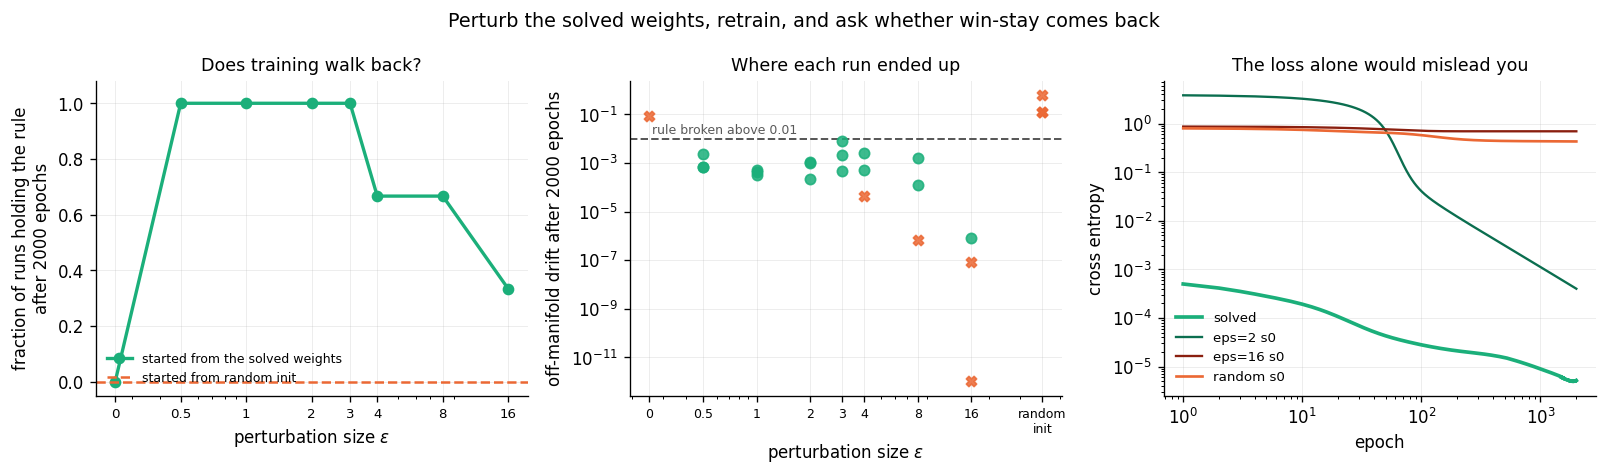

recovery from a perturbation, by size:
   eps =    0   0/1 held the rule
   eps =  0.5   3/3 held the rule
   eps =    1   3/3 held the rule
   eps =    2   3/3 held the rule
   eps =    3   3/3 held the rule
   eps =    4   2/3 held the rule
   eps =    8   2/3 held the rule
   eps =   16   1/3 held the rule

every seed came back up to eps = 3 (||dtheta|| about 13, against a solved weight vector of norm 21)
the largest size any seed came back from is eps = 16; from eps = 4 up it depends on the seed

Note the eps = 0 row: it is the §2.2 run, and it does NOT hold, for the reason §2.3
isolated. So this ladder is not measuring distance from a stable point, because the
point is not stable under this objective. It measures whether the optimiser returns to
the right machine at all, and it does, from knocks of the same order as the whole
weight vector.

random init, same optimiser and same 2000 epochs: 0/3 held the rule, final drift 0.13, 0.12, 0.62
Those runs reach 100% accuracy on the data 

In [15]:
# --- 2.6 -- the ladder as a picture ---------------------------------------------------------
pert = [r for r in RESULTS if r["kind"] == "perturbed"]
rand = [r for r in RESULTS if r["kind"] == "random"]
pos  = {e: (0.25 if e == 0 else e) for e in EPS_LADDER}      # eps = 0 needs a spot on a log axis

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.0))

ax = axes[0]
fr = [(pos[e], np.mean([r["ok"] for r in pert if r["eps"] == e])) for e in EPS_LADDER]
ax.plot([x for x, _ in fr], [f for _, f in fr], "o-", color=C_SOLVED, lw=2.0, ms=6,
        label="started from the solved weights")
ax.axhline(np.mean([r["ok"] for r in rand]), color=C_TRAINED, ls="--", lw=1.5,
           label="started from random init")
ax.set_xscale("log")
ax.set_xticks([pos[e] for e in EPS_LADDER])
ax.set_xticklabels(["0"] + [f"{e:g}" for e in EPS_LADDER[1:]], fontsize=8)
ax.set_xlabel(r"perturbation size $\varepsilon$")
ax.set_ylabel(f"fraction of runs holding the rule\nafter {EPOCHS} epochs")
ax.set_ylim(-0.05, 1.08); ax.set_title("Does training walk back?", fontsize=10.5)
ax.legend(fontsize=7.5, loc="lower left")

ax = axes[1]
for r in pert:
    ax.scatter(pos[r["eps"]], max(r["drift_f"], 1e-12),
               color=(C_SOLVED if r["ok"] else C_TRAINED), s=38, alpha=0.85, zorder=3,
               marker=("o" if r["ok"] else "X"))
for r in rand:
    ax.scatter(40, max(r["drift_f"], 1e-12), color=C_TRAINED, s=38, marker="X", alpha=0.85, zorder=3)
ax.axhline(DRIFT_TOL, color=C_RULE, ls="--", lw=1.2)
ax.text(0.26, DRIFT_TOL * 1.6, f"rule broken above {DRIFT_TOL:g}", fontsize=7.5, color=C_RULE)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xticks([pos[e] for e in EPS_LADDER] + [40])
ax.set_xticklabels(["0"] + [f"{e:g}" for e in EPS_LADDER[1:]] + ["random\ninit"], fontsize=7.5)
ax.set_xlabel(r"perturbation size $\varepsilon$")
ax.set_ylabel(f"off-manifold drift after {EPOCHS} epochs")
ax.set_title("Where each run ended up", fontsize=10.5)

ax = axes[2]
ep = np.arange(1, EPOCHS + 1)
for tag, col, lw in (("solved", C_SOLVED, 2.2), ("eps=2 s0", "#0b6e4f", 1.4),
                     ("eps=16 s0", "#8a1f0f", 1.4), ("random s0", C_TRAINED, 1.6)):
    if tag in CURVES: ax.plot(ep, CURVES[tag], color=col, lw=lw, label=tag)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("epoch"); ax.set_ylabel("cross entropy")
ax.set_title("The loss alone would mislead you", fontsize=10.5)
ax.legend(fontsize=8)

fig.suptitle("Perturb the solved weights, retrain, and ask whether win-stay comes back",
             fontsize=11.5)
plt.tight_layout(); plt.show()

_by_eps = {e: [r["ok"] for r in pert if r["eps"] == e] for e in EPS_LADDER}
_nz     = [e for e in EPS_LADDER if e > 0]
_all_ok = [e for e in _nz if all(_by_eps[e])]
_any_ok = [e for e in _nz if any(_by_eps[e])]
print("recovery from a perturbation, by size:")
for e in EPS_LADDER:
    v = _by_eps[e]
    print(f"   eps = {e:>4g}   {sum(v)}/{len(v)} held the rule")
_mixed = [e for e in _nz if not all(_by_eps[e])]
if _all_ok:
    print(f"\nevery seed came back up to eps = {max(_all_ok):g} "
          f"(||dtheta|| about "
          f"{np.mean([r['dtheta'] for r in pert if r['eps'] == max(_all_ok)]):.0f}, "
          f"against a solved weight vector of norm {np.linalg.norm(TH0):.0f})")
else:
    print("\nno perturbation size had all seeds come back")
if _mixed:
    print(f"the largest size any seed came back from is eps = {max(_any_ok):g}; from "
          f"eps = {min(_mixed):g} up it depends on the seed")
_eps0_ok = _by_eps[0.0][0]
if not _eps0_ok:
    print(f"\nNote the eps = 0 row: it is the §2.2 run, and it does NOT hold, for the reason §2.3")
    print(f"isolated. So this ladder is not measuring distance from a stable point, because the")
    print(f"point is not stable under this objective. It measures whether the optimiser returns to")
    print(f"the right machine at all, and it does, from knocks of the same order as the whole")
    print(f"weight vector.")
else:
    print(f"\nThe eps = 0 row held at this budget, so the ladder here reads as distance from a point")
    print(f"training is content to sit at.")
print(f"\nrandom init, same optimiser and same {EPOCHS} epochs: "
      f"{sum(r['ok'] for r in rand)}/{len(rand)} held the rule, "
      f"final drift {', '.join('%.2f' % r['drift_f'] for r in rand)}")
print("Those runs reach 100% accuracy on the data and still get the rule wrong off it, which is")
print("the same failure the committed fits show. Starting point, not budget, is what separates them.")

## 3. What these two checks establish

**Q1. The one hidden unit is running the FSC, literally.** Its hidden state takes exactly two
values on the data, one per memory state, and there are exactly four internal configurations, one
per reachable row of the transition table. The mechanism is a single gate: the update gate goes to
1.0000 on a win, which holds the state unchanged, and to about 0.1 on a loss, which overwrites it.
Nothing about win-stay/lose-shift was written into the solver; it appeared because the network was
required to be the machine. That is the answer to "is the representation there": it is there and it
is exact, which is why an exhaustive four-row table beats a projection for the solved network.

The trained H=1 fit has the same two states in the sense that a threshold on $h$ recovers the FSC's
state on every trial, and PCA and t-SNE both separate them. Its states are blobs rather than
points, and §1.6 charges for that off the manifold.

**Q2. The answer split in two, and the second half was the surprise.**

*Can training sit at the solved point?* Under cross entropy alone, yes, completely: 2000 epochs
leave the off-manifold drift at $10^{-8}$, where it started, while the loss falls by orders of
magnitude. Under the objective that actually produced the committed fits, no. The L1 penalty on the
recurrent weights erodes the solution steadily, the update gate's "hold" slips from 0.99999997 to
0.995, and by epoch 2000 the rule is broken off the manifold. §2.3 isolates the penalty as the
cause by switching it off and changing nothing else.

The conflict is structural rather than unlucky. Saturating a gate takes a large weight, and L1 is a
charge on exactly that. So the pipeline's own regulariser prices the exact solution out, and it
does so **silently**: on-manifold accuracy stays pinned at 100% and the loss keeps falling the
whole time the machine is decaying. This is the clearest example so far of why these notebooks
measure behaviour off the manifold rather than trusting the loss.

*Can training walk back to it?* Yes, and from remarkably far. Perturbations up to $\varepsilon = 3$
are undone by every seed, including ones that destroy the network outright first, and at least one
seed recovers from every size tested. The boundary where it becomes seed-dependent is at a
perturbation whose norm is comparable to the entire solved weight vector.

Meanwhile the same optimiser at the same budget, started from random init, does not get there at
all: 100% accuracy on the data, and the rule wrong off it, which is exactly what the committed fits
do. So the drift in those fits is not evidence that the solved region repels gradient descent, and
it is not an epoch-budget problem. It is about where the optimiser starts, plus a regulariser that
charges rent on staying.

### What this does not establish

- **One dataset, one architecture, one hidden size.** Everything here is H=1 GRU on `det_init`,
  whose fitted FSC is deterministic. `analytical_rnn_fsc_rwsls.ipynb` is the stochastic case and it
  does not behave the same way.
- **The L1 result is not a recommendation to drop the penalty.** It explains one specific failure
  on one deterministic dataset where there is nothing to regularise against. What `l1_weight = 0`
  would do to fits on stochastic data is a separate question this notebook does not ask.
- **The recovery boundary is not a basin radius.** Gaussian noise of a given size is one family of
  directions. A perturbation of the same norm chosen adversarially could break earlier. The ladder
  shows recovery is robust, not that every direction is safe.
- **Nothing here says gradient descent cannot find the solved region from random init.** Three
  random runs is a control, not a search. The claim is only that the ones that produced the
  committed fits did not.
- **The four-row table is on the data manifold.** Off it the solved network still has a defined
  answer, which is what §1.6 probes, but the enumeration itself covers only reachable situations.